#   分析和可视化人口普查租金数据

请在 http://geoffboeing.com/2015/11/landscape-us-rents/ 查看数据和地图的演示

基于原作者 gboeing 提供了 notebook 与经纬度数据，使用 pandas 清洗并合并城市租金数据；计算 2010→2014 的租金增长率并用 geopandas/folium 可视化美国城市租金分布，识别增长最快的前 10 个城市。将分析封装为可复现的 Jupyter Notebook，并提交包含 requirements.txt 与交互 HTML 地图的 GitHub 项目页面。

In [90]:
import pandas as pd, numpy as np
import statsmodels.api as sm, matplotlib.font_manager as fm
import matplotlib.pyplot as plt, matplotlib.cm as cm
from mpl_toolkits.basemap import Basemap
from geopandas import GeoDataFrame
from shapely.geometry import Point
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['SimHei']
rcParams['axes.unicode_minus'] = False

%matplotlib inline

In [89]:
# 定义用于绘图的字体
family = 'SimHei'
title_font = fm.FontProperties(family=family, style='normal', size=18, weight='normal', stretch='normal')
label_font = fm.FontProperties(family=family, style='normal', size=16, weight='normal', stretch='normal')
ticks_font = fm.FontProperties(family=family, style='normal', size=14, weight='normal', stretch='normal')

In [44]:
# 读取 2014 年的租金数据
rent14 = pd.read_csv('../data/rent_latlong.csv')
# 对数据列重命名
rent14 = rent14.rename(columns={'geo_id2':'geo_id_14'})    #2014 年的地理编码
# 剔除无关的数据列
# 2014 年地理编码（唯一标识）、大都市区名称、城市 + 州简称、合同租金中位数、纬度、经度
rent14 = rent14[['geo_id_14', 'msa_name', 'city_state', 'median_contract_rent', 'latitude', 'longitude']]
rent14.head()

,geo_id_14,msa_name,city_state,median_contract_rent,latitude,longitude
0,10140,"Aberdeen, WA Micro Area","Aberdeen, WA",626,46.975371,-123.815722
1,10180,"Abilene, TX Metro Area","Abilene, TX",613,32.448736,-99.733144
2,10300,"Adrian, MI Micro Area","Adrian, MI",556,41.897547,-84.037166
3,10420,"Akron, OH Metro Area","Akron, OH",627,41.081445,-81.519005
4,10460,"Alamogordo, NM Micro Area","Alamogordo, NM",700,32.899532,-105.960265


In [45]:
# 读取 2010 年的租金数据，并规范化列名，剔除无关的数据列
rent10 = pd.read_csv('../data/ACS_10_1YR_B25058_metro_micro/ACS_10_1YR_B25058.csv')
rent10 = rent10.rename(columns={'GEO.id':'geo_id', 
                            'GEO.id2':'geo_id_10', 
                            'GEO.display-label':'msa_name', 
                            'HD01_VD01':'median_rent_10',
                            'HD02_VD01':'margin_error'})
# 2010 年的地理编码、2010 年该地区的合同租金中位数
rent10 = rent10[['geo_id_10', 'median_rent_10']]
rent10.head()

,geo_id_10,median_rent_10
0,10140,562
1,10180,554
2,10300,537
3,10420,579
4,10500,477


## 合并2014年和2010年的ACS租金数据

一些人口普查统计区的名称和代码在2010年和2014年之间发生了变化。为那些发生变化的区域建立一个字典，将2014年的代码映射到2010年的代码。其他的一些是全新的，还有一些在2014年被删除的只需忽略它们，因为除非它们在两年都有数据，否则无法比较。

In [39]:
# create a dict to map 2014 codes to 2010 codes for those that changed
# 创建一个字典，将2014年的代码映射到已更改的2010年的代码
# 因为部分地区的地理编码在 2010-2014 年间发生了变更（比如 bloomington il 的编码从 2010 年的 14060 变成了 2014 年的 14010），需要通过这个字典记录 “变动的编码对应关系”，方便后续匹配两年的数据。
codes_14_10 = {  #2014_code:2010_code
    14010:14060, #bloomington il
    15680:30500, #lexington park md
    16060:32060, #marion il
    17200:30100, #lebanon nh
    25840:37820, #pendleton
    26090:26100, #holland
    29200:29140, #lafayette
    38240:43860, #pinehurst
    41400:20620, #salem oh
    49220:32270, #wisconsin rapids
    31080:31100, #los angeles
    42200:42060, #santa barbara
    46520:26180, #honolulu
    48260:44600} #steubenville

# 创建一个新列以包含 2010 年的地理编码，方便后面将 rent14 和 rent10 合并起来
rent14['geo_id_10'] = rent14['geo_id_14'].map(lambda x: codes_14_10[x] if x in codes_14_10.keys() else x)

In [38]:
# 现在在 2010 年的地理编码上合并 2014 年的租金数据和 2010 年的租金数据
rent = pd.merge(rent14, rent10, on='geo_id_10')  #两表都有共同列‘geo_id_10’
rent.head()

,geo_id_14,msa_name,city_state,median_contract_rent,latitude,longitude,geo_id_10,median_rent_10
0,10140,"Aberdeen, WA Micro Area","Aberdeen, WA",626,46.975371,-123.815722,10140,562
1,10180,"Abilene, TX Metro Area","Abilene, TX",613,32.448736,-99.733144,10180,554
2,10300,"Adrian, MI Micro Area","Adrian, MI",556,41.897547,-84.037166,10300,537
3,10420,"Akron, OH Metro Area","Akron, OH",627,41.081445,-81.519005,10420,579
4,10500,"Albany, GA Metro Area","Albany, GA",480,31.578507,-84.155741,10500,477


In [43]:
# 计算 2010-2014 年各地区租金中位数的变化百分比，然后按涨幅从低到高排序，筛选出涨幅最低（甚至下跌）的前 5 个地区并展示其名称和涨幅百分比，用于分析租金变化的极端情况
# 租金变化百分比 = (2014 年租金 / 2010 年租金 - 1) × 100
rent['rent_change_pct'] = (rent['median_contract_rent'] / rent['median_rent_10'] - 1) * 100
rent.sort_values(by='rent_change_pct')[['msa_name', 'rent_change_pct']].head()

,msa_name,rent_change_pct
414,"Seneca, SC Micro Area",-14.417745
413,"Sebring, FL Metro Area",-11.992945
69,"Carson City, NV Metro Area",-9.015257
464,"Valdosta, GA Metro Area",-7.992895
442,"Talladega-Sylacauga, AL Micro Area",-7.049608


## 导入人口数据并与租金数据合并

包含 2014 年的人口预估数和 2010 年的人口普查数值

In [42]:
# 读取 2014 年人口统计数据的 CSV 文件，规范化列名，剔除无关列数据
pops = pd.read_csv('../data/PEP_2014_PEPANNRES/PEP_2014_PEPANNRES.csv', encoding='utf-8')
pops = pops.rename(columns={'GEO.id2':'geo_id_14',           #2014 年的地理编码
                              'rescen42010':'pop_10',        #2010 年人口普查的常住人口数
                              'respop72014':'pop_est_14'})   #2014 年人口预估数
pops = pops[['geo_id_14', 'pop_10', 'pop_est_14']]
pops.head()

,geo_id_14,pop_10,pop_est_14
0,10100,40602,42391
1,10140,72797,70818
2,10180,165252,168592
3,10220,37492,38005
4,10300,99892,99047


In [51]:
# 将租金数据集与人口数据集合并
df = pd.merge(rent, pops, on='geo_id_14')
df.head()

,geo_id_14,msa_name,city_state,median_contract_rent,latitude,longitude,geo_id_10,median_rent_10,rent_change_pct,pop_10,pop_est_14
0,10140,"Aberdeen, WA Micro Area","Aberdeen, WA",626,46.975371,-123.815722,10140,562,11.387900,72797,70818
1,10180,"Abilene, TX Metro Area","Abilene, TX",613,32.448736,-99.733144,10180,554,10.649819,165252,168592
2,10300,"Adrian, MI Micro Area","Adrian, MI",556,41.897547,-84.037166,10300,537,3.538175,99892,99047
3,10420,"Akron, OH Metro Area","Akron, OH",627,41.081445,-81.519005,10420,579,8.290155,703200,703825
4,10500,"Albany, GA Metro Area","Albany, GA",480,31.578507,-84.155741,10500,477,0.628931,157308,154925


In [99]:
# 计算 2010-2014 年各地区人口变化的百分比，按涨幅从低到高排序后，筛选出人口跌幅最大（或涨幅最低）的前 5 个地区，仅展示地区名称和人口变化百分比，用于分析人口变化的极端情况
# 人口变化百分比 = (2014 年预估人口 / 2010 年普查人口 - 1) × 100
df['pop_change_pct'] = (df['pop_est_14'] / df['pop_10'] - 1) * 100
df.sort_values(by='pop_change_pct')[['msa_name', 'pop_change_pct']].head()
# df.head()
df.isna().sum()   # 查询是否有缺失值

geo_id_14               0
msa_name                0
city_state              0
median_contract_rent    0
latitude                0
longitude               0
geo_id_10               0
median_rent_10          0
rent_change_pct         0
pop_10                  0
pop_est_14              0
pop_change_pct          0
dtype: int64

## 通过一些散点图初步探索数据中的关系


<Axes: title={'center': '租金变化百分比与人口变化百分比'}, xlabel='pop_change_pct', ylabel='rent_change_pct'>

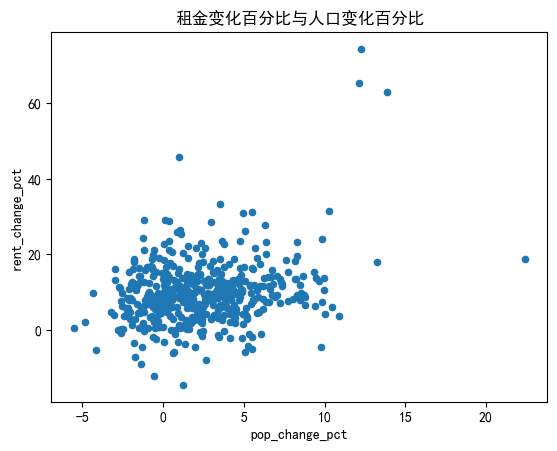

In [88]:
# 租金变化百分比与人口变化百分比
df.plot(kind='scatter', x='pop_change_pct', y='rent_change_pct', title='租金变化百分比与人口变化百分比')
# 说明了人口增长是推动租金上涨的重要驱动力，但也存在个别特殊案例（图中高处的两个点），它们的租金涨幅远超人口增长幅度。

<Axes: title={'center': '2014年人口 vs 2010年人口'}, xlabel='pop_10', ylabel='pop_est_14'>

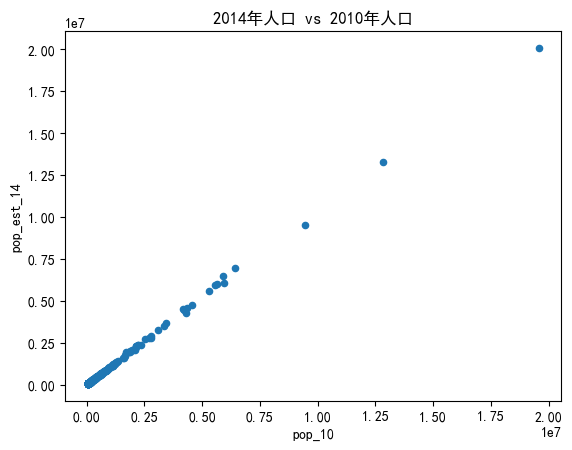

In [92]:
# 2014年人口 vs 2010年人口
df.plot(kind='scatter', x='pop_10', y='pop_est_14', title='2014年人口 vs 2010年人口')
# 2010-2014 年间，各地区人口规模的相对排序基本稳定，有着极强的线性相关性。

<Axes: title={'center': '2014年中位租金与2010年中位租金'}, xlabel='median_rent_10', ylabel='median_contract_rent'>

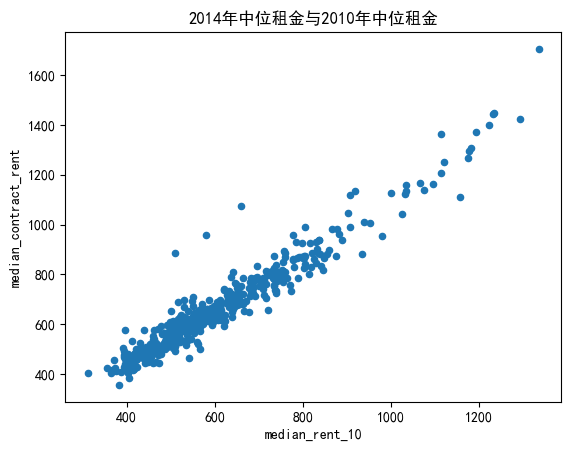

In [93]:
# 2014年中位租金与2010年中位租金
df.plot(kind='scatter', x='median_rent_10', y='median_contract_rent', title='2014年中位租金与2010年中位租金')
# 反映出美国大都市区的租金格局在这 4 年间稳定性极强，全国范围内租金整体上涨，而且高租金地区的租金涨幅普遍高于低租金地区。数据点高度集中在左下角（2010 年租金 400-800 美元区间），说明美国绝大多数大都市区的租金处于中低水平。

<Axes: title={'center': '2014年中位数租金与2014年人口'}, xlabel='pop_est_14', ylabel='median_contract_rent'>

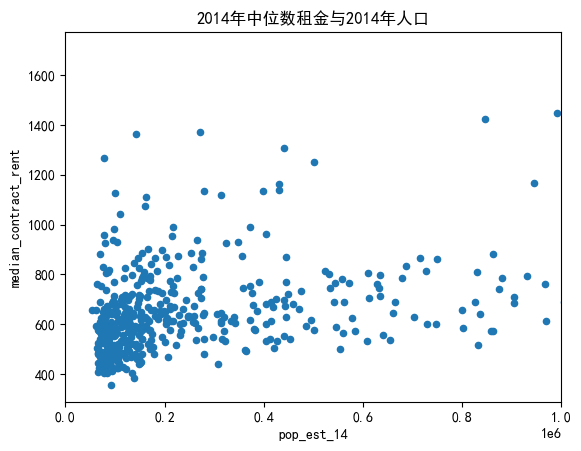

In [94]:
# 2014年中位数租金与2014年人口
df.plot(kind='scatter', x='pop_est_14', y='median_contract_rent', xlim=[0, 1000000], title='2014年中位数租金与2014年人口')
# 人口越多租金并非越高，虽然存在一定的正相关，但相关性不强。说明高租金并非只由 “城市规模大” 决定，还受其他因素（如经济活力、住房供应、地理位置、产业结构等）强烈影响。绝大多数大都市区人口规模不大，租金处于中低区间，高租金城市是少数。

<Axes: title={'center': '2010年中位数租金与2010年人口'}, xlabel='pop_10', ylabel='median_rent_10'>

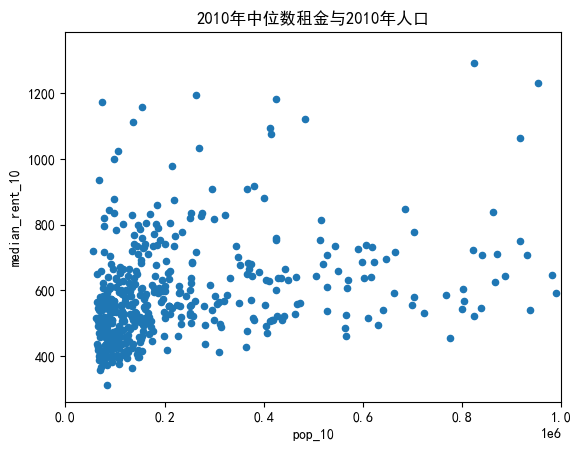

In [98]:
# 2010年中位数租金与2010年人口
df.plot(kind='scatter', x='pop_10', y='median_rent_10', xlim=[0, 1000000], title='2010年中位数租金与2010年人口')
# 人口越多租金总体略高，但并不是决定性因素，呈弱正相关性，大部分地区是中低租金的中小型城市，高租金城市是少数（且分布分散）。

<Axes: title={'center': '2014年中位数租金与2010-2014年租金百分比变化'}, xlabel='rent_change_pct', ylabel='median_contract_rent'>

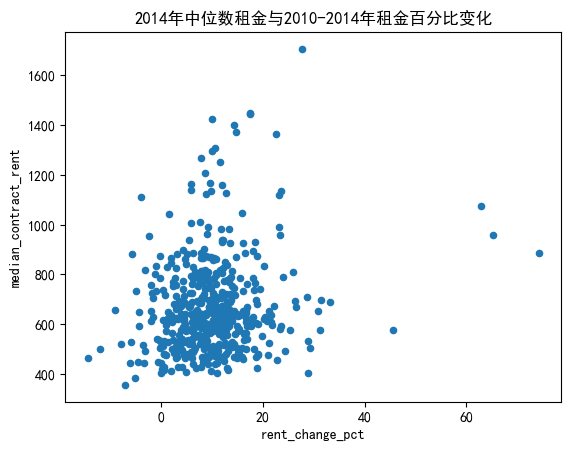

In [96]:
# 2014年中位数租金与2010-2014年租金百分比变化
df.plot(kind='scatter', x='rent_change_pct', y='median_contract_rent', title='2014年中位数租金与2010-2014年租金百分比变化')
# 说明 2010-2014 年美国大都市区租金整体呈上涨趋势，无明显下跌的地区，2014 年租金水平越高的地区，租金涨幅（百分比）倾向于更大，但相关性不强，存在明显分化。高租金城市中既有持续高速增长的核心区域，也有增长平缓的成熟区域；低租金城市中既有快速崛起的新兴区域，也有增长停滞的区域。

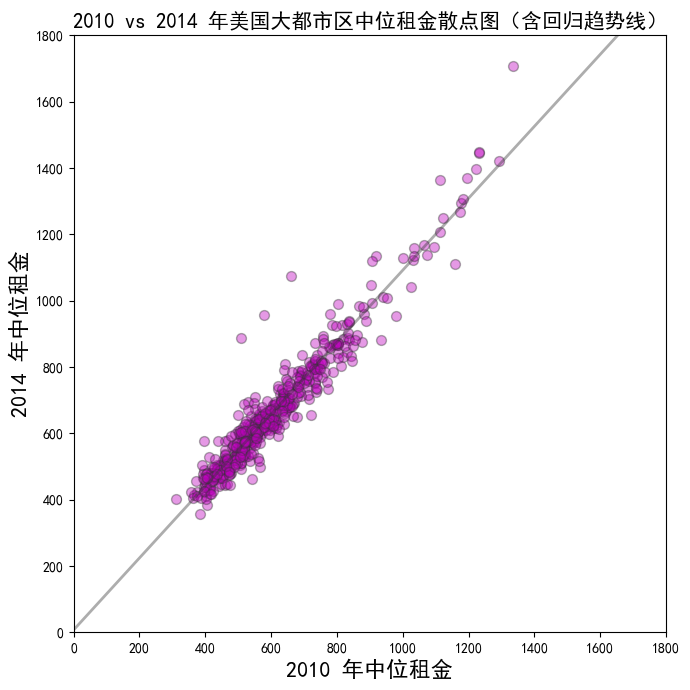

In [119]:
# 绘制2014年中位租金与2010年中位租金的对比图
fig, ax = plt.subplots()
fig.set_size_inches(7, 7)
axis_min = 0
axis_max = 1800

# regress 2014 rent on 2010 rent
# 将 2014 年中位租金对 2010 年中位租金进行回归
X = df['median_rent_10']
Y = df['median_contract_rent']
results = sm.OLS(Y, sm.add_constant(X)).fit()   # 核心作用是量化 “2010 年租金每涨 1 美元，2014 年租金涨多少”

# 计算回归线的估计y值
X_line = X.copy()
# 手动给 X 轴添加 “最小值 0” 和 “最大值 1800” 的点，确保回归线能覆盖整个坐标轴范围（从 0 到 1800 美元）
X_line.loc[axis_min] = axis_min
X_line.loc[axis_max] = axis_max
# 根据回归系数计算回归线的 Y 坐标（2014 年预测租金）
Y_est = X_line * results.params['median_rent_10'] + results.params['const']


# 绘制点、回归线和1:1线性关系线
# ax.plot([axis_min, axis_max], [axis_min, axis_max], 'k-', color='k', alpha=0.3, linewidth=2)
ax.plot(X_line, Y_est, c='#333333', alpha=0.4, linewidth=2)
# 绘制散点图（每个点代表一个大都市区）
ax.scatter(X, Y, c='m', edgecolor='#333333', alpha=0.4, s=50)

ax.set_xlim([axis_min, axis_max])
ax.set_ylim([axis_min, axis_max])

# 2014年与2010年各大都市区的中位数租金
ax.set_title('2010 vs 2014 年美国大都市区中位租金散点图（含回归趋势线）', fontproperties=title_font, size=15)
ax.set_xlabel('2010 年中位租金', fontproperties=label_font)
ax.set_ylabel('2014 年中位租金', fontproperties=label_font)

fig.tight_layout()
fig.savefig('../images/2010 vs 2014 年美国大都市区中位租金散点图（含回归趋势线）.png', dpi=300)
plt.show()

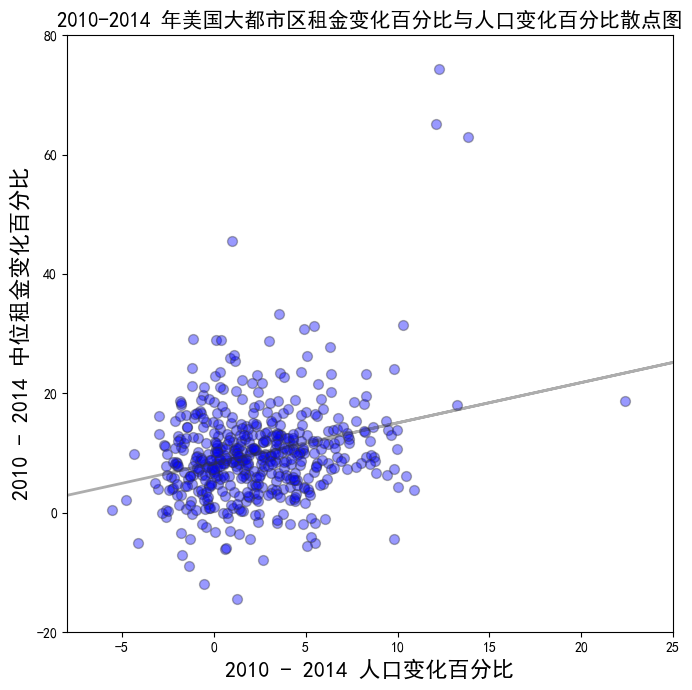

In [124]:
# 绘制2010-2014年中位数租金变化百分比与人口变化百分比的关系图
fig, ax = plt.subplots()
fig.set_size_inches(7, 7)

# 将租金变化百分比对人口变化百分比进行回归
X = df['pop_change_pct']
Y = df['rent_change_pct']
results = sm.OLS(Y, sm.add_constant(X)).fit()

# 计算回归线的估计y值
X_line = X.copy()
X_line.loc[-10] = -10
X_line.loc[30] = 30
Y_est = X_line * results.params['pop_change_pct'] + results.params['const']

# 绘制点，回归线
ax.plot(X_line, Y_est, c='#333333', alpha=0.4, linewidth=2)
ax.scatter(X, Y, c='b', edgecolor='#333333', alpha=0.4, s=50)

ax.set_xlim([-8, 25])
ax.set_ylim([-20, 80])

ax.set_title('2010-2014 年美国大都市区租金变化百分比与人口变化百分比散点图', fontproperties=title_font, size=15)
ax.set_xlabel('2010 - 2014 人口变化百分比', fontproperties=label_font)
ax.set_ylabel('2010 - 2014 中位租金变化百分比', fontproperties=label_font)

fig.tight_layout()
fig.savefig('../images/2010 - 2014 年美国大都市区租金变化百分比与人口变化百分比散点图.png', dpi=300)
plt.show()

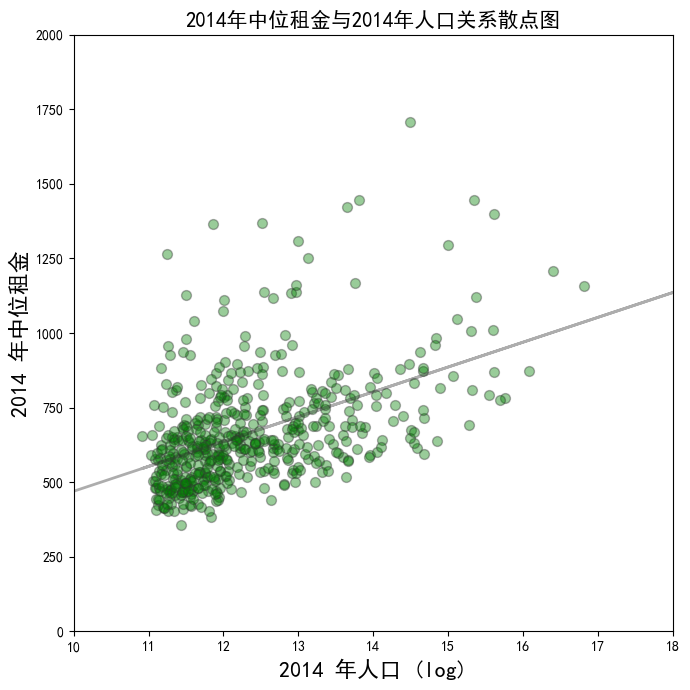

In [125]:
# 绘制2014年中位租金与2014年人口的关系
fig, ax = plt.subplots()
fig.set_size_inches(7, 7)

# 将租金对人口进行回归
X = np.log(df['pop_est_14'])
Y = df['median_contract_rent']
results = sm.OLS(Y, sm.add_constant(X)).fit()

# 计算回归线的估计y值
X_line = X.copy()
X_line.loc[0] = 0
X_line.loc[20] = 20
Y_est = X_line * results.params['pop_est_14'] + results.params['const']

# 绘制点，回归线
ax.plot(X_line, Y_est, c='#333333', alpha=0.4, linewidth=2)
ax.scatter(X, Y, c='g', edgecolor='#333333', alpha=0.4, s=50)

ax.set_xlim([10, 18])
ax.set_ylim([0, 2000])

ax.set_title('2014年中位租金与2014年人口关系散点图', fontproperties=title_font, size=15)
ax.set_xlabel('2014 年人口 (log)', fontproperties=label_font)
ax.set_ylabel('2014 年中位租金', fontproperties=label_font)

fig.tight_layout()
fig.savefig('../images/2014年中位租金与2014年人口关系散点图.png', dpi=300)
plt.show()

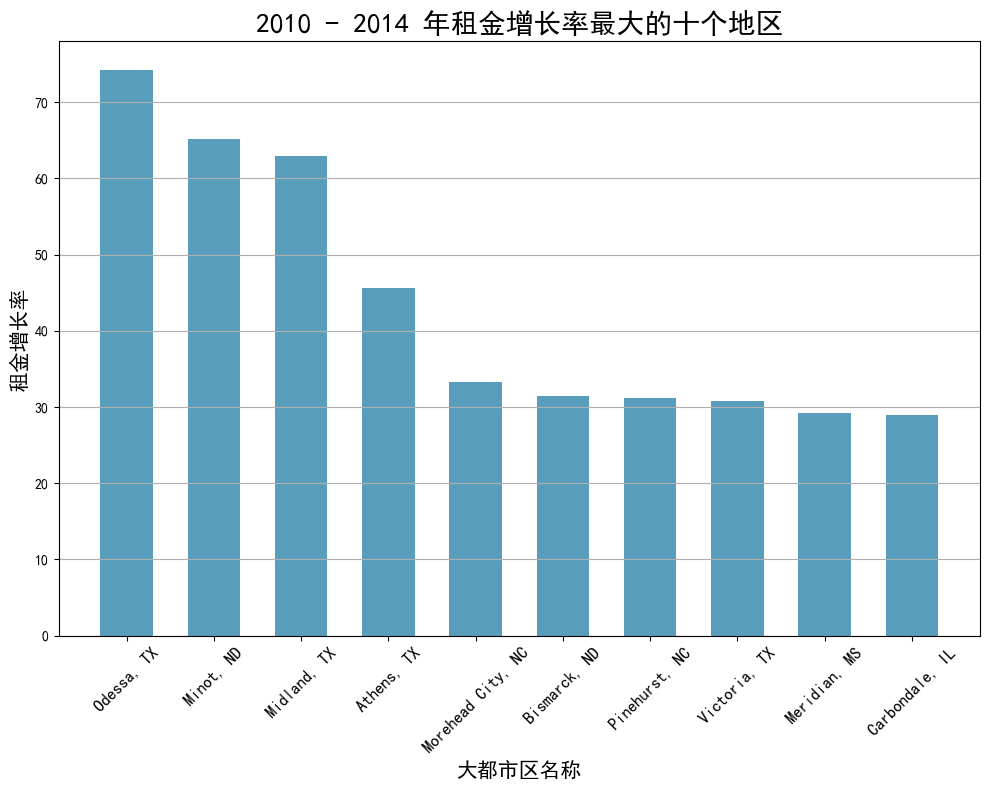

In [171]:
# 筛选 2010 - 2014 年租金增长率并绘制增长最快 Top10 柱状图
df_sorted = df.sort_values(by='rent_change_pct', ascending=False)
top10_rent_growth = df_sorted[['geo_id_14','msa_name','city_state','rent_change_pct']]
top10_rent_growth.head(10)

# 绘制柱状图
plt.figure(figsize=(10,8))

# 绘图数据
x = top10_rent_growth['city_state']
y = top10_rent_growth['rent_change_pct']
plt.bar(x, y, color='#2E86AB', alpha=0.8, width=0.6)

# 旋转字体防止堆叠
plt.xticks(
    rotation=45,
    fontsize=12  # 调整横轴文字大小，进一步避免拥挤
)

plt.grid(axis='y')

plt.title('2010 - 2014 年租金增长率最大的十个地区',size=20)
plt.xlabel('大都市区名称',size=15)
plt.ylabel('租金增长率',size=15)

# 优化布局（避免文字被画布截断）
plt.tight_layout()
plt.savefig('../images/2010 - 2014 年租金增长率最大的十个地区.png', dpi=300)
plt.show()